# Financial Data Explorer

Goal: build statistical intuition for how equity returns actually behave.

In [29]:
import sys
sys.path.append('..')
import os

from config import TICKERS, START, END
from src.data_loader import fetch_prices
from src.returns import *
from src.stats import *
import scipy
import matplotlib.pyplot as plt

BASE_DIR = os.path.abspath("..")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

os.makedirs(PROCESSED_DIR, exist_ok=True)

## 1. Load data

Live Yahoo Finance data on a normal machine; synthetic GARCH-style fallback otherwise.

In [30]:
# df = fetch_prices(TICKERS,START,END)
df = pd.read_csv("../data/raw/prices.csv",index_col="Date",parse_dates=True)
df.head()

,AAPL,GS,JNJ,JPM,KO,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-02,37.469204,144.753738,103.791008,80.836510,37.341599,94.193161,3.373053,20.674667,27.913776,49.664757
2019-01-03,33.737000,142.633240,102.141716,79.687675,37.110859,90.727966,3.169262,20.024000,27.770231,48.902206
2019-01-04,35.177216,147.294861,103.855980,82.625404,37.850830,94.947655,3.372308,21.179333,27.943682,50.705212
2019-01-07,35.098919,148.111099,103.189781,82.682846,37.357510,95.068764,3.550842,22.330667,28.272636,50.968899
2019-01-08,35.767994,147.564133,105.586494,82.526947,37.779228,95.758057,3.462443,22.356667,28.470020,51.339485


In [31]:
# print(df.info())
# print(df.describe())

## 2. Log returns

`r_t = ln(P_t / P_{t-1})`

Why log, not simple returns? Time-additivity: a 5-day log return is just
the sum of 5 daily log returns. Simple returns don't have this property,
which matters the moment you start compounding or annualizing anything.

In [32]:
returns = log_ret(df)
returns.head()

,AAPL,GS,JNJ,JPM,KO,MSFT,NVDA,TSLA,WMT,XOM
Date,,,,,,,,,,
2019-01-03,-0.104924,-0.014757,-0.016018,-0.014314,-0.006198,-0.037482,-0.062319,-0.031978,-0.005156,-0.015473
2019-01-04,0.041803,0.032160,0.016644,0.036202,0.019743,0.045460,0.062099,0.056094,0.006226,0.036206
2019-01-07,-0.002228,0.005526,-0.006435,0.000695,-0.013119,0.001275,0.051587,0.052935,0.011703,0.005187
2019-01-08,0.018883,-0.003700,0.022961,-0.001887,0.011225,0.007224,-0.025210,0.001164,0.006957,0.007245
2019-01-09,0.016839,0.006253,-0.007957,-0.001692,-0.019352,0.014198,0.019476,0.009438,-0.003262,0.005261


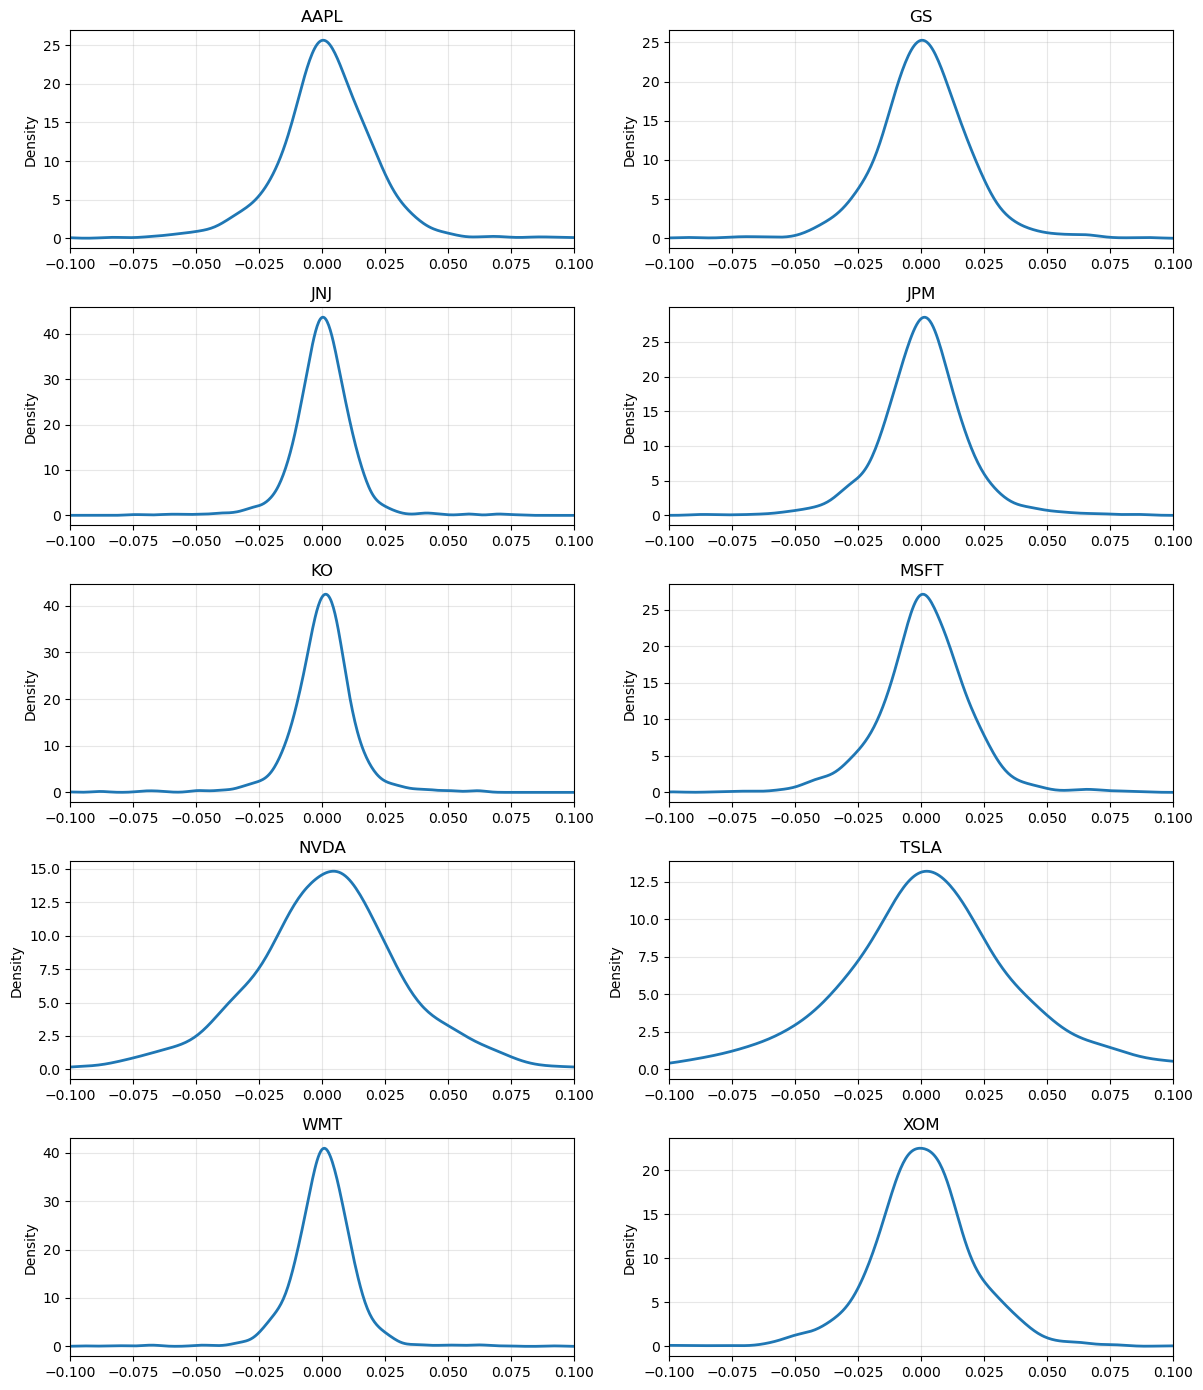

In [33]:
fig, axes = plt.subplots(5, 2, figsize=(12, 14))

for ax, col in zip(axes.ravel(), returns.columns):
    returns[col].plot(kind="kde", ax=ax, linewidth=2)
    ax.set_title(col)
    ax.set_xlim(-0.1, 0.1)
    ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig("../plots/kde_plot.png", dpi=300, bbox_inches="tight")
plt.show()

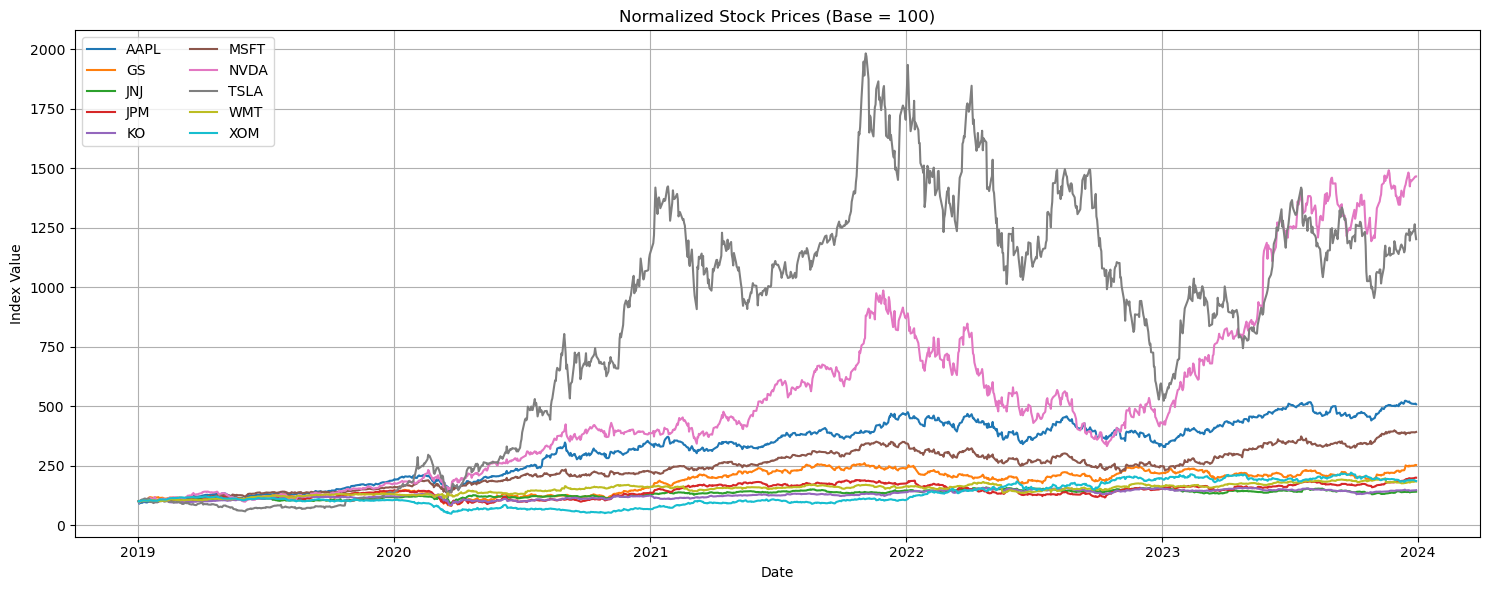

In [34]:
normalized = df / df.iloc[0] * 100

plt.figure(figsize=(15, 6))

for col in normalized.columns:
    plt.plot(normalized.index, normalized[col], label=col)

plt.title("Normalized Stock Prices (Base = 100)")
plt.xlabel("Date")
plt.ylabel("Index Value")
plt.legend(loc="upper left", ncol=2)
plt.grid(True)
plt.tight_layout()
fig.savefig("../plots/normalized_stock.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
weekly_ret = week_ret(df)
monthly_ret = month_ret(df)
yearly_ret =year_ret(df)


returns.to_csv(os.path.join(PROCESSED_DIR, "daily_log_returns.csv"))
weekly_ret.to_csv(os.path.join(PROCESSED_DIR, "weekly_returns.csv"))
monthly_ret.to_csv(os.path.join(PROCESSED_DIR, "monthly_returns.csv"))
yearly_ret.to_csv(os.path.join(PROCESSED_DIR, "yearly_returns.csv"))

## 3. Descriptive statistics

The two stats that matter most beyond mean/vol:

- **Skewness** — negative = fatter left tail = bigger crash risk than the
  symmetric picture suggests
- **Excess kurtosis** — positive means fatter tails than Normal. This is
  near-universal in real equity returns, and it's the reason quants don't
  trust plain Gaussian models for tail risk.

In [36]:
stats = descriptive(df).sort_values('vol_annual', ascending=False)
stats

,mean_daily,mean_annual,std_daily,vol_annual,skewness,excess_kurtosis,min,max,sharpe_naive
TSLA,170.8875,43063.6423,108.3045,1719.2810,-0.1552,-1.2062,11.9313,409.9700,25.0475
MSFT,227.3541,57293.2362,72.0580,1143.8848,-0.1126,-0.9945,90.7280,375.4061,50.0865
GS,258.1811,65061.6252,71.3772,1133.0775,-0.2038,-1.5217,116.6198,377.3182,57.4203
AAPL,120.2081,30292.4336,46.2943,734.8994,-0.3893,-1.1477,33.7370,195.8926,41.2198
XOM,62.9121,15853.8596,23.9805,380.6787,0.3704,-1.1806,23.8236,109.6244,41.6463
JPM,114.8819,28950.2471,22.3311,354.4960,-0.0866,-1.2278,66.7633,161.3232,81.6659
JNJ,135.6959,34195.3549,16.7869,266.4835,-0.3699,-1.1398,93.4335,164.6817,128.3207
NVDA,17.6924,4458.4949,12.4502,197.6401,1.0188,0.2545,3.1693,50.3151,22.5587
KO,47.7127,12023.5935,6.6242,105.1564,-0.0890,-1.2351,31.1034,58.4277,114.3401
WMT,42.0225,10589.6581,6.2607,99.3851,-0.3971,-0.6182,27.7702,54.9699,106.5518


In [37]:
risk = risk_analysis(returns)

# Portfolio Risk Assuming:
#   Equal Portfolio Weights
#   Perfect Positive Correlation (ρ = 1) Between All Assets

n = len(stats)
weights = np.ones(n) / n
portfolio_risk = np.sum(weights * stats["vol_annual"])

risk

,Parametric VaR,Historical VaR,Expected Shortfall,Sharpe Ratio,Semi Deviation,Sortino Ratio,Max Drawdown,CAGR,Calmar Ratio
AAPL,-0.0321,-0.0312,-0.0473,0.8554,0.0152,1.1413,-0.3518,0.3146,0.8944
GS,-0.0332,-0.0291,-0.0463,0.4144,0.0154,0.5556,-0.4902,0.1410,0.2877
JNJ,-0.0203,-0.0168,-0.0297,0.0914,0.0094,0.1210,-0.2902,0.0496,0.1710
JPM,-0.0324,-0.0286,-0.0453,0.2773,0.0153,0.3637,-0.4730,0.0914,0.1933
KO,-0.0220,-0.0183,-0.0341,0.1252,0.0115,0.1472,-0.3860,0.0551,0.1426
MSFT,-0.0305,-0.0295,-0.0436,0.7332,0.0143,0.9846,-0.4061,0.2547,0.6271
NVDA,-0.0512,-0.0484,-0.0705,0.9478,0.0219,1.4022,-0.7187,0.4998,0.6954
TSLA,-0.0651,-0.0637,-0.0957,0.6929,0.0302,0.9357,-0.7988,0.3322,0.4159
WMT,-0.0224,-0.0190,-0.0317,0.3246,0.0112,0.4023,-0.2679,0.1021,0.3811
XOM,-0.0350,-0.0330,-0.0496,0.2148,0.0153,0.3028,-0.6370,0.0668,0.1049


## 4. Is the data normal? (it isn't)

Three tests, same null hypothesis: H0 = returns are normally distributed.
- Jarque-Bera: joint test on skew + kurtosis
- Shapiro-Wilk: general-purpose normality test
- D'Agostino K²: combines skew-test and kurtosis-test statistics

p < 0.05 → reject normality.

In [38]:
result = normality(returns)
result

,Stock,Jarque-Bera Stat,Jarque-Bera p,JB Reject,Shapiro Stat,Shapiro p,SW Reject,D'Agostino Stat,D'Agostino p,DA Reject
0,AAPL,1551.486,0.0,True,0.940,0.0,True,169.286,0.0,True
1,GS,4880.569,0.0,True,0.905,0.0,True,229.503,0.0,True
2,JNJ,3479.748,0.0,True,0.894,0.0,True,204.557,0.0,True
3,JPM,8699.272,0.0,True,0.879,0.0,True,264.949,0.0,True
4,KO,4986.619,0.0,True,0.878,0.0,True,364.401,0.0,True
5,MSFT,2959.615,0.0,True,0.935,0.0,True,208.860,0.0,True
6,NVDA,857.299,0.0,True,0.966,0.0,True,123.174,0.0,True
7,TSLA,698.104,0.0,True,0.954,0.0,True,125.015,0.0,True
8,WMT,12195.389,0.0,True,0.848,0.0,True,315.457,0.0,True
9,XOM,1176.194,0.0,True,0.950,0.0,True,144.513,0.0,True


## 5. Rolling volatility — clustering, not constancy

A single annualized-vol number hides regime structure. Volatility
clusters: calm periods persist, turbulent periods persist. This is
exactly the empirical pattern GARCH(1,1) models:

σ²_t = ω + α·r²_{t-1} + β·σ²_{t-1}

In [39]:
roll = rolling_metrics(returns)
roll

,rolling_mean,rolling_vol,rolling_sharpe
AAPL,0.199558,0.126527,1.577202
GS,1.189082,0.226672,5.245832
JNJ,0.503676,0.139382,3.613630
JPM,1.070884,0.099167,10.798827
KO,0.315443,0.110090,2.865329
MSFT,0.143511,0.165348,0.867932
NVDA,0.108973,0.273669,0.398193
TSLA,0.192860,0.345951,0.557479
WMT,-0.591518,0.281573,-2.100759
XOM,-0.303627,0.178184,-1.704010


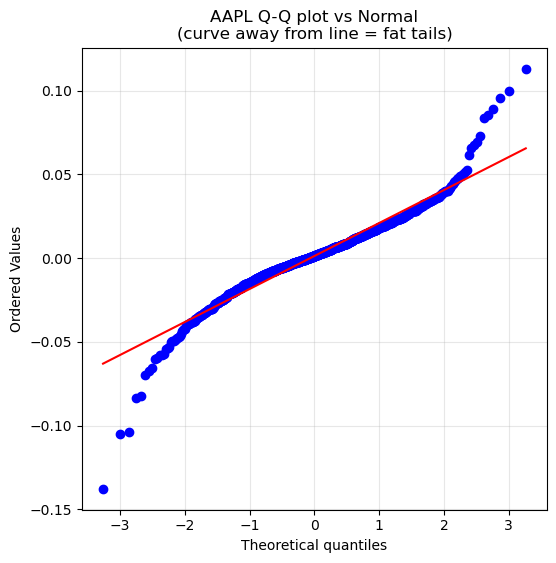

In [40]:
ticker = 'AAPL'
data = returns[ticker]

fig, ax = plt.subplots(figsize=(6,6))
scipy.stats.probplot(data, dist='norm', plot=ax)
ax.set_title(f'{ticker} Q-Q plot vs Normal\n(curve away from line = fat tails)')
ax.grid(alpha=0.3)
plt.savefig("../plots/qq_plot.png", dpi=300, bbox_inches="tight")
plt.show()

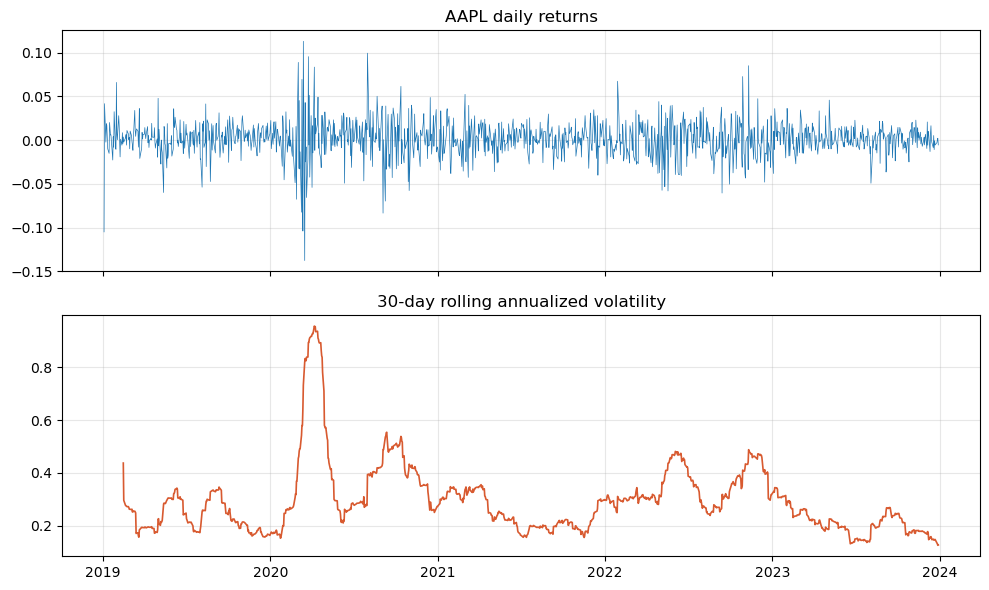

In [41]:
rolling_vol = returns[ticker].rolling(30).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(10,6), sharex=True)
axes[0].plot(returns.index, returns[ticker], linewidth=0.5)
axes[0].set_title(f'{ticker} daily returns')
axes[0].grid(alpha=0.3)

axes[1].plot(rolling_vol.index, rolling_vol, color='#D85A30', linewidth=1.2)
axes[1].set_title('30-day rolling annualized volatility')
axes[1].grid(alpha=0.3)
plt.tight_layout()
fig.savefig("../plots/rolling_ann.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Drawdown — what investors actually feel

Max drawdown is often more meaningful than volatility to allocators: it's
the worst peak-to-trough loss an investor would have actually lived
through. It's a direct input to the Calmar ratio used later in backtesting.

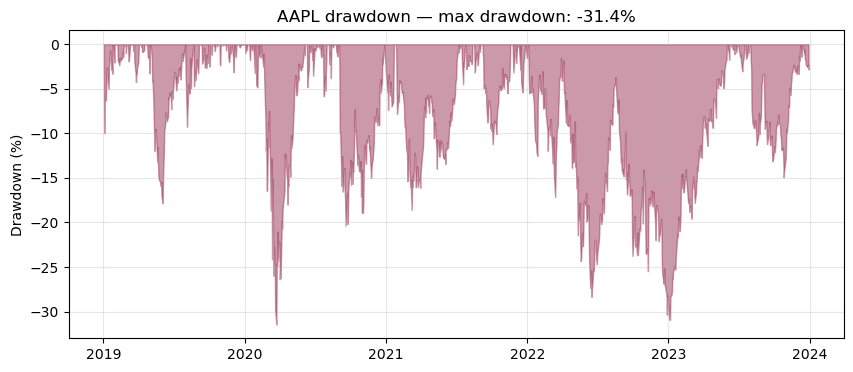

In [42]:
dd = drawdown_series(df[ticker])

fig, ax = plt.subplots(figsize=(10,4))
ax.fill_between(dd.index, dd['drawdown']*100, 0, alpha=0.5, color='#993556')
ax.set_title(f"{ticker} drawdown — max drawdown: {dd['drawdown'].min()*100:.1f}%")
ax.set_ylabel('Drawdown (%)')
ax.grid(alpha=0.3)
fig.savefig("../plots/drawdown_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## Takeaways to carry forward

1. Real return data is **not Normal** — fat tails are the rule, not the exception
2. Volatility is **not constant** — it clusters, motivating GARCH (P6)
3. Skew and kurtosis matter as much as mean and variance for risk
4. Drawdown captures something Sharpe ratio alone misses
5. All of this is the empirical foundation for VaR/ES, GARCH,
   and portfolio optimization